# SME-Financial-Decision--Risk-Prediction-Dataset

A project to evaluate loan performance across SME sectors and assess credit risk metrics

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
## Load the data as a data frame by using URL
fin_data_url="Finanical_data_sme.csv"
df = pd.read_csv(fin_data_url)
print(f"Dataset Loaded. Shape: {df.shape}")

Dataset Loaded. Shape: (10000, 33)


In [5]:
df.head()

,Has_Financial_Questions,SME_Age,SME_Type,Industry_Sector,SME_Size_Category,Literacy_Accounting,Literacy_Budgeting,Literacy_Investment_Evaluation,Literacy_Credit_Knowledge,Risk_Awareness,...,Decision_Capital_Allocation,Decision_CashFlow_Management,Analysis_Accounting_Tools,Analysis_Financial_Ratios,Analysis_Forecasting,Analysis_Benchmarking,Liquidity_Stability,Uses_Digital_Finance,Annual_Revenue_Category,Financial_Distress
0,YES,3,3,1,1,3,3,3,5.0,2,...,5,5,3,3,3,5.0,4,0,Low,0.0
1,YES,2,2,2,3,2,2,3,5.0,2,...,3,3,2,2,3,5.0,5,0,Medium,0.0
2,YES,3,2,1,3,3,3,5,5.0,2,...,3,3,3,3,5,5.0,3,0,Low,0.0
3,YES,1,2,2,2,4,4,5,5.0,2,...,5,5,4,4,5,5.0,5,0,Medium,0.0
4,YES,2,2,3,4,3,3,3,5.0,4,...,3,3,3,3,3,5.0,5,0,Medium,NaN


In [6]:
df.columns

Index(['Has_Financial_Questions', 'SME_Age', 'SME_Type', 'Industry_Sector',
       'SME_Size_Category', 'Literacy_Accounting', 'Literacy_Budgeting',
       'Literacy_Investment_Evaluation', 'Literacy_Credit_Knowledge',
       'Risk_Awareness', 'Risk_Evaluation', 'Risk_Mitigation_Strategies',
       'Risk_Taking_Willingness', 'Assessment_Data_Driven',
       'Assessment_Expert_Consultation', 'Assessment_Scenario_Analysis',
       'Assessment_Internal_Evaluation', 'Decision_Autonomy',
       'Decision_Consultation', 'Decision_Financial_Advisor',
       'Decision_Strategic_Alignment', 'Decision_Investment_Choices',
       'Decision_Loan_Approval', 'Decision_Capital_Allocation',
       'Decision_CashFlow_Management', 'Analysis_Accounting_Tools',
       'Analysis_Financial_Ratios', 'Analysis_Forecasting',
       'Analysis_Benchmarking', 'Liquidity_Stability', 'Uses_Digital_Finance',
       'Annual_Revenue_Category', 'Financial_Distress'],
      dtype='object')

In [7]:
# descriptive statistics
df.describe()

,SME_Age,SME_Type,Industry_Sector,SME_Size_Category,Literacy_Accounting,Literacy_Budgeting,Literacy_Investment_Evaluation,Literacy_Credit_Knowledge,Risk_Awareness,Risk_Evaluation,...,Decision_Loan_Approval,Decision_Capital_Allocation,Decision_CashFlow_Management,Analysis_Accounting_Tools,Analysis_Financial_Ratios,Analysis_Forecasting,Analysis_Benchmarking,Liquidity_Stability,Uses_Digital_Finance,Financial_Distress
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9500.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9502.000000,10000.000000,10000.000000,9500.000000
mean,1.877800,2.551500,2.979400,2.768800,3.185100,3.194200,4.062400,3.409684,2.851700,2.214800,...,3.342000,3.379700,3.341300,3.179300,3.216200,4.046800,3.515997,2.976600,0.612100,0.303158
std,0.681406,0.982774,1.160134,1.101121,1.006449,0.924214,0.884186,1.047534,1.013218,1.243228,...,0.639278,0.681744,0.725167,0.902459,0.936347,0.881072,1.158934,1.417199,0.487296,0.459647
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,1.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,2.000000,1.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,2.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,1.000000,0.000000
75%,2.000000,3.000000,4.000000,3.000000,4.000000,4.000000,5.000000,4.000000,4.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000
max,3.000000,4.000000,5.000000,5.000000,10.000000,5.000000,5.000000,5.000000,5.000000,10.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,10.000000,5.000000,1.000000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Has_Financial_Questions         10000 non-null  object 
 1   SME_Age                         10000 non-null  int64  
 2   SME_Type                        10000 non-null  int64  
 3   Industry_Sector                 10000 non-null  int64  
 4   SME_Size_Category               10000 non-null  int64  
 5   Literacy_Accounting             10000 non-null  int64  
 6   Literacy_Budgeting              10000 non-null  int64  
 7   Literacy_Investment_Evaluation  10000 non-null  int64  
 8   Literacy_Credit_Knowledge       9500 non-null   float64
 9   Risk_Awareness                  10000 non-null  int64  
 10  Risk_Evaluation                 10000 non-null  int64  
 11  Risk_Mitigation_Strategies      10000 non-null  int64  
 12  Risk_Taking_Willingness         1

In [9]:
# Columns with missing values 
# Literacy_Credit_Knowledge       9500 non-null 
# Assessment_Expert_Consultation  9500 non-null
# Decision_Strategic_Alignment    9500 non-null
# Analysis_Benchmarking           9502 non-null
# FFinancial_Distress              9500 non-null 
null_cols = ['Literacy_Credit_Knowledge', 'Assessment_Expert_Consultation', 
             'Decision_Strategic_Alignment', 'Analysis_Benchmarking', 'Financial_Distress']

In [10]:
# Fill missing values with median values
for col in null_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [11]:
# Count uique values
df["Industry_Sector"].nunique()

5

In [12]:
# Get unique values in "Industry_Sector"
df["Industry_Sector"].unique()

array([1, 2, 3, 4, 5])

In [13]:
# Count Frequency of Each Unique Value
# Excludes NaN
df["Industry_Sector"].value_counts()

Industry_Sector
3    3087
2    2395
4    2335
1    1128
5    1055
Name: count, dtype: int64

In [14]:
# Get unique values in "SME_Type"
df["SME_Type"].nunique()


4

In [15]:
# Map Industry_Sector to mumeric values to textual lables
sector_map = {1: 'Technology', 2: 'Retail', 3: 'Manufacturing', 4: 'Agriculture', 5: 'Services'}
df['Industry_Sector_Label'] = df['Industry_Sector'].map(sector_map)

#### The composite score translates raw categorical values into a single, quantifiable **risk profile** for each SME.

### Formula Breakdown

$$\text{Composite Risk Score} = (2 \times \text{Financial Distress}) + \text{Risk Taking Willingness} - \text{Risk Mitigation Strategies}$$

In [16]:
# Risk Score: Higher Financial Distress & Risk Taking Willingness, Lower Risk Mitigation
df['Composite_Risk_Score'] = df['Financial_Distress'] * 2 + df['Risk_Taking_Willingness'] - df['Risk_Mitigation_Strategies']

# Profitability Proxy: High Revenue + High Liquidity + Strategic Alignment
rev_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['Revenue_Numeric'] = df['Annual_Revenue_Category'].map(rev_map)
df['Profitability_Index'] = df['Revenue_Numeric'] * df['Liquidity_Stability']

# Capital Proxy: Decision_Capital_Allocation scale combined with SME_Size
df['Capital_Scale_Index'] = df['Decision_Capital_Allocation'] * df['SME_Size_Category']

print("Data Cleaning and Feature Engineering Complete.")

Data Cleaning and Feature Engineering Complete.


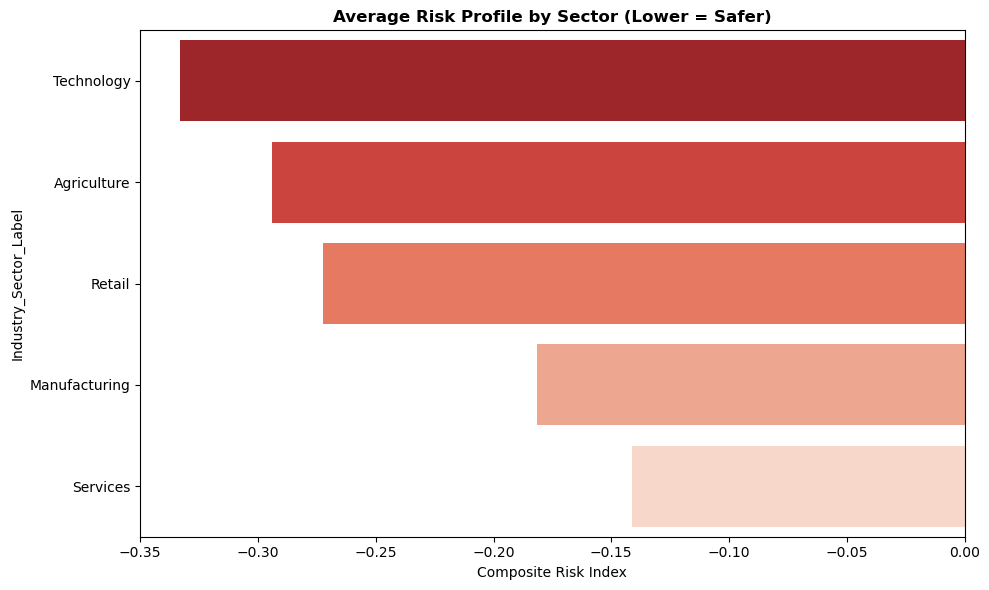

In [17]:
# ==============================================================================
# Highest / Lowest Risk Sector
# ==============================================================================
plt.figure(figsize=(10, 6))
risk_by_sector = df.groupby('Industry_Sector_Label')['Composite_Risk_Score'].mean().sort_values()
sns.barplot(x=risk_by_sector.values, y=risk_by_sector.index, palette='Reds_r')
plt.title('Average Risk Profile by Sector (Lower = Safer)', fontsize=12, fontweight='bold')
plt.xlabel('Composite Risk Index')
plt.tight_layout()
plt.savefig('images/risk_by_sector.png', dpi=300)
plt.show()
plt.close()

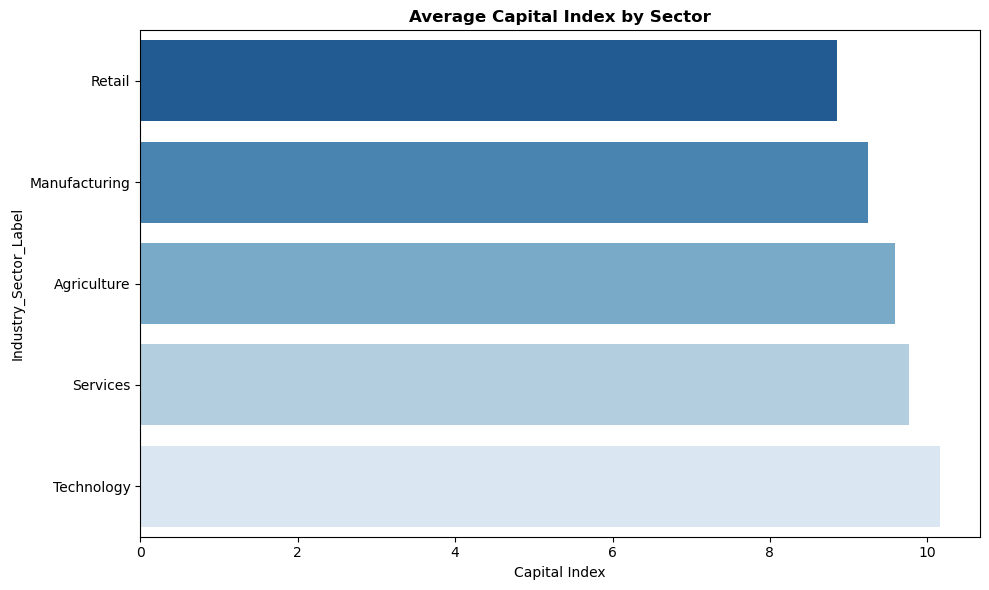

In [18]:
# ==============================================================================
# Highest / Lowest Capital Allocation
# ==============================================================================
plt.figure(figsize=(10, 6))
capital_by_sector = df.groupby('Industry_Sector_Label')['Capital_Scale_Index'].mean().sort_values()
sns.barplot(x=capital_by_sector.values, y=capital_by_sector.index, palette='Blues_r')
plt.title('Average Capital Index by Sector', fontsize=12, fontweight='bold')
plt.xlabel('Capital Index')
plt.tight_layout()
plt.savefig('images/capital_by_sector.png', dpi=300)
plt.show()
plt.close()

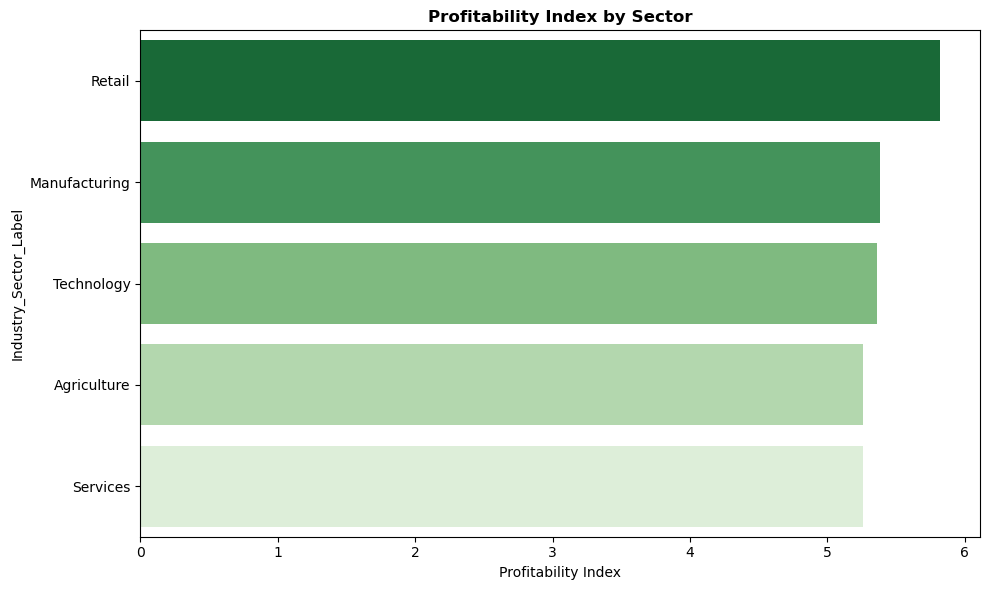

In [19]:
# ==============================================================================
# Most Profitability Sectors
# ==============================================================================
plt.figure(figsize=(10, 6))
profit_by_sector = df.groupby('Industry_Sector_Label')['Profitability_Index'].mean().sort_values(ascending=False)
sns.barplot(x=profit_by_sector.values, y=profit_by_sector.index, palette='Greens_r')
plt.title('Profitability Index by Sector', fontsize=12, fontweight='bold')
plt.xlabel('Profitability Index')
plt.tight_layout()
plt.savefig('images/profitability_by_sector.png', dpi=300)
plt.show()
plt.close()

<Figure size 1000x600 with 0 Axes>

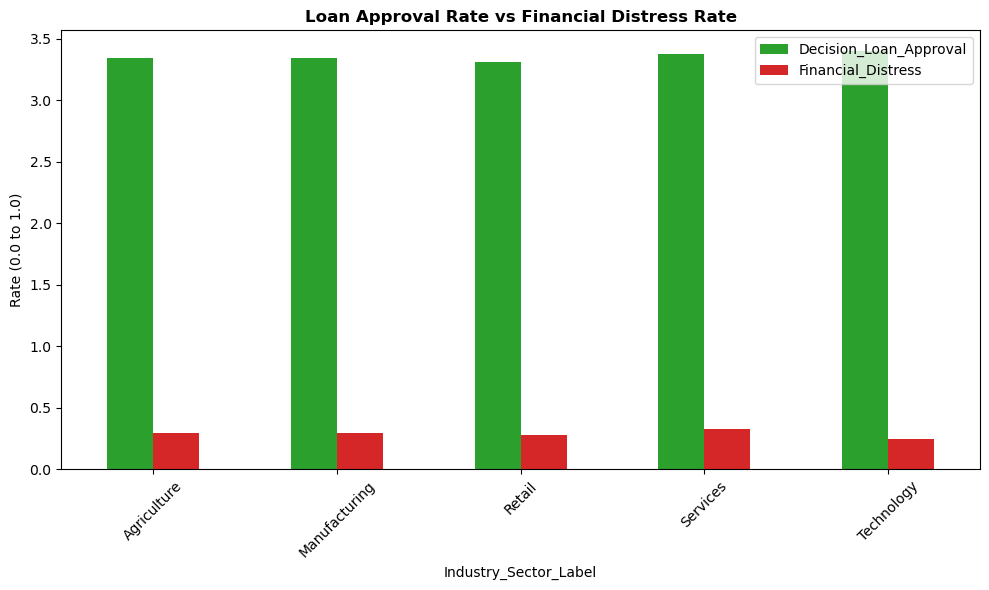

In [20]:
# ==============================================================================
# Loan Approval vs Financial Distress Across Sectors
# ==============================================================================
plt.figure(figsize=(10, 6))
approval_distress = df.groupby('Industry_Sector_Label')[['Decision_Loan_Approval', 'Financial_Distress']].mean()
ax = approval_distress.plot(kind='bar', figsize=(10, 6), rot=45, color=['#2ca02c', '#d62728'])
plt.title('Loan Approval Rate vs Financial Distress Rate', fontsize=12, fontweight='bold')
plt.ylabel('Rate (0.0 to 1.0)')
plt.tight_layout()
plt.savefig('images/approval_vs_distress_by_sector.png', dpi=300)
plt.show()
plt.close()

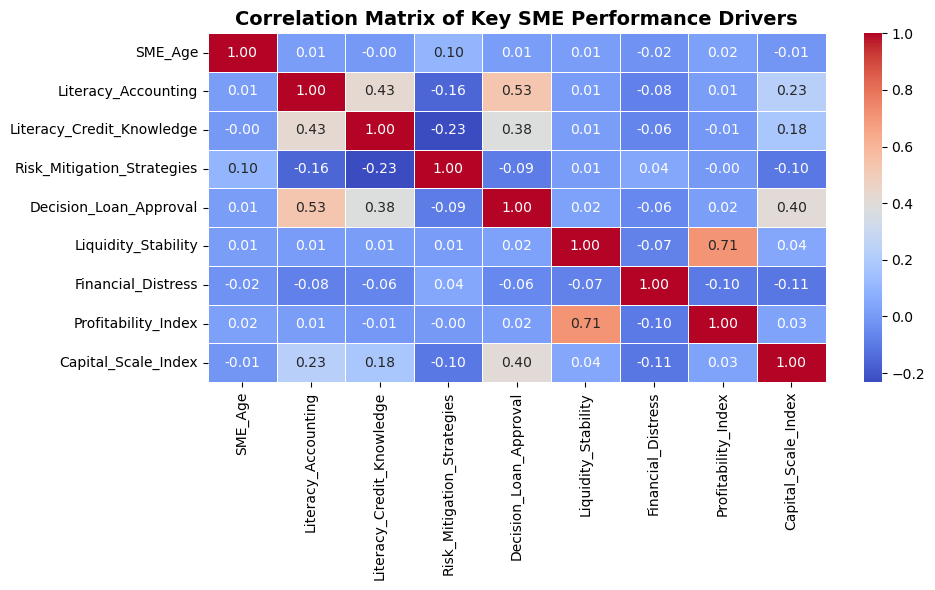

In [21]:
# ==============================================================================
# Correlation Matrix
# ==============================================================================
plt.figure(figsize=(10, 6))

# Select key numerical performance indicators
corr_cols = [
    'SME_Age', 'Literacy_Accounting', 'Literacy_Credit_Knowledge', 
    'Risk_Mitigation_Strategies', 'Decision_Loan_Approval', 
    'Liquidity_Stability', 'Financial_Distress', 'Profitability_Index', 'Capital_Scale_Index'
]

corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Correlation Matrix of Key SME Performance Drivers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_matrix2.png', dpi=300)
plt.show()